# TECA2 — Atividade 4 · 1ª Parte (pipeline clássico)
**Visão Computacional (TECA2 20261) · UFG · 2026/1** — Grupo: Henryque Oliveira

Notebook do pipeline clássico de inspeção. Roda ponta-a-ponta no Colab
(`!pip install` no bootstrap) e localmente com `uv`. Seeds fixas (=42) para
reprodutibilidade.

## Bootstrap — dependências, caminhos e seeds

In [1]:
import sys, os, subprocess

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _in_colab():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "numpy", "opencv-python", "matplotlib", "scipy"], check=True)

# Localiza a raiz do projeto (a que contém src/ e data/)
_cands = [".", "..", os.getcwd(), "/content/teca2-atividade4"]
ROOT = next((p for p in _cands
             if os.path.isdir(os.path.join(p, "src"))
             and os.path.isdir(os.path.join(p, "data"))), None)
assert ROOT, "Raiz do projeto (src/ + data/) não encontrada — ajuste ROOT."
ROOT = os.path.abspath(ROOT)
sys.path.insert(0, ROOT)
DATA = os.path.join(ROOT, "data")
RESULTS = os.path.join(ROOT, "results"); os.makedirs(RESULTS, exist_ok=True)

import random, numpy as np
SEED = 42
random.seed(SEED); np.random.seed(SEED)

import cv2, matplotlib
import matplotlib.pyplot as plt
print("ROOT =", ROOT)
print("numpy", np.__version__, "| opencv", cv2.__version__)

ROOT = /home/henryque/Documents/JOB/atividade4
numpy 2.5.0 | opencv 4.13.0


---
## Bloco 2 — Segmentação + rotulação

**Objetivo (CLAUDE.md §4.2):** Otsu *próprio* sobre `cenas_cinza`, comparar com
`cenas_bin`; morfologia mínima (Cap. 9); `connectedComponentsWithStats`.

**Critério de aceite:** label map colorido; *nº de componentes ≈ objetos visíveis.*

Toda a lógica vive em [`src/segmentacao.py`](../src/segmentacao.py). O limiar de
Otsu é implementado na mão (histograma + somas cumulativas da variância
entre-classes); `cv2.threshold(..., THRESH_OTSU)` entra **só como validação**.

In [2]:
import json
from src import segmentacao as seg

Z = np.load(os.path.join(DATA, "cenas_esteira.npz"), allow_pickle=True)
cenas_cinza = Z["cenas_cinza"]      # (10, 200, 800) uint8
cenas_bin   = Z["cenas_bin"]        # (10, 200, 800) uint8  — Otsu de referência
META = json.load(open(os.path.join(DATA, "metadados_cenas.json")))
N_CENAS = cenas_cinza.shape[0]
print(f"{N_CENAS} cenas de {cenas_cinza.shape[1]}x{cenas_cinza.shape[2]} px")

10 cenas de 200x800 px


### 2.1 — Otsu DO ZERO vs `cv2` (validação cruzada)

Validação 1: o limiar calculado na mão tem de coincidir com o do OpenCV.
Validação 2: a binarização resultante tem de bater com `cenas_bin`
(acurácia de pixel, IoU, Dice).

In [3]:
print(f"{'cena':>4} {'t_meu':>6} {'t_cv2':>6} {'acc_px':>8} {'IoU':>7} {'Dice':>7}")
res = []
accs, ious = [], []
for i in range(N_CENAS):
    g = cenas_cinza[i]
    t_cv, _ = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    r = seg.segmentar_cena(g, abertura=3, area_min=0)
    conc = seg.concordancia(r["mask_morf"], cenas_bin[i])
    res.append(r); accs.append(conc["acuracia_px"]); ious.append(conc["iou"])
    print(f"{i:>4} {r['limiar']:>6} {int(t_cv):>6} {conc['acuracia_px']*100:>7.2f}% "
          f"{conc['iou']:>7.3f} {conc['dice']:>7.3f}")

assert all(r["limiar"] == int(cv2.threshold(cenas_cinza[i],0,255,
           cv2.THRESH_BINARY+cv2.THRESH_OTSU)[0]) for i, r in enumerate(res)), \
       "limiar próprio divergiu do cv2!"
print(f"\n✔ Otsu próprio == cv2 em todas as cenas. "
      f"Acurácia de pixel média {np.mean(accs)*100:.2f}% | IoU médio {np.mean(ious):.3f}")

cena  t_meu  t_cv2   acc_px     IoU    Dice
   0    112    112   99.99%   0.997   0.999
   1    112    112   99.99%   0.996   0.998
   2    112    112   99.98%   0.995   0.998
   3    112    112   99.99%   0.997   0.998
   4    112    112   99.99%   0.997   0.999
   5    112    112   99.99%   0.997   0.998
   6    112    112   99.98%   0.996   0.998
   7    112    112   99.98%   0.997   0.998
   8    112    112   99.98%   0.996   0.998
   9    112    112   99.99%   0.997   0.999

✔ Otsu próprio == cv2 em todas as cenas. Acurácia de pixel média 99.99% | IoU médio 0.997


### 2.2 — Pipeline em camadas (uma cena)

Visualização dos estágios: cinza → Otsu próprio → diferença vs referência →
morfologia → mapa de rótulos colorido.

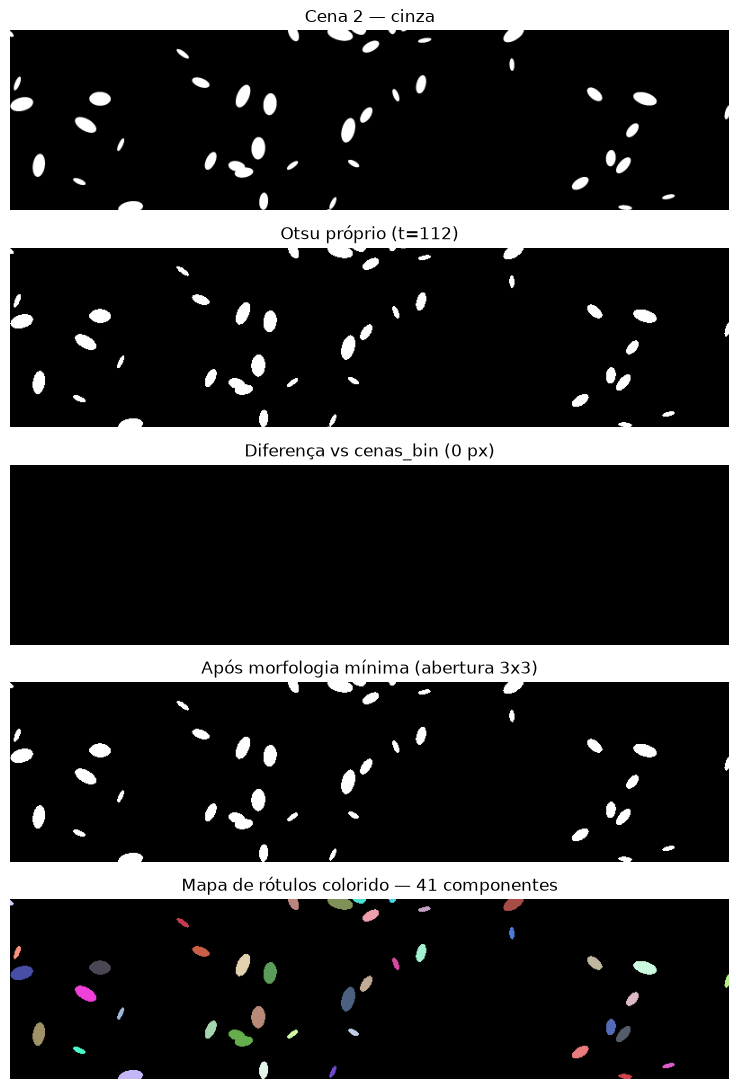

In [4]:
ci = 2  # cena de exemplo
g = cenas_cinza[ci]; r = res[ci]
diff = (((r["mask_bin"] > 0) != (cenas_bin[ci] > 0)).astype(np.uint8)) * 255
lblcolor = seg.mapa_rotulos_colorido(r["labels"])

fig, ax = plt.subplots(5, 1, figsize=(13, 11))
ax[0].imshow(g, cmap="gray");                 ax[0].set_title(f"Cena {ci} — cinza")
ax[1].imshow(r["mask_bin"], cmap="gray");     ax[1].set_title(f"Otsu próprio (t={r['limiar']})")
ax[2].imshow(diff, cmap="gray");              ax[2].set_title(f"Diferença vs cenas_bin ({(diff>0).sum()} px)")
ax[3].imshow(r["mask_morf"], cmap="gray");    ax[3].set_title("Após morfologia mínima (abertura 3x3)")
ax[4].imshow(lblcolor);                        ax[4].set_title(f"Mapa de rótulos colorido — {r['n']} componentes")
for a in ax: a.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "bloco2_pipeline_camadas.png"), dpi=110, bbox_inches="tight")
plt.show()

### 2.3 — Mapas de rótulos coloridos (todas as cenas)

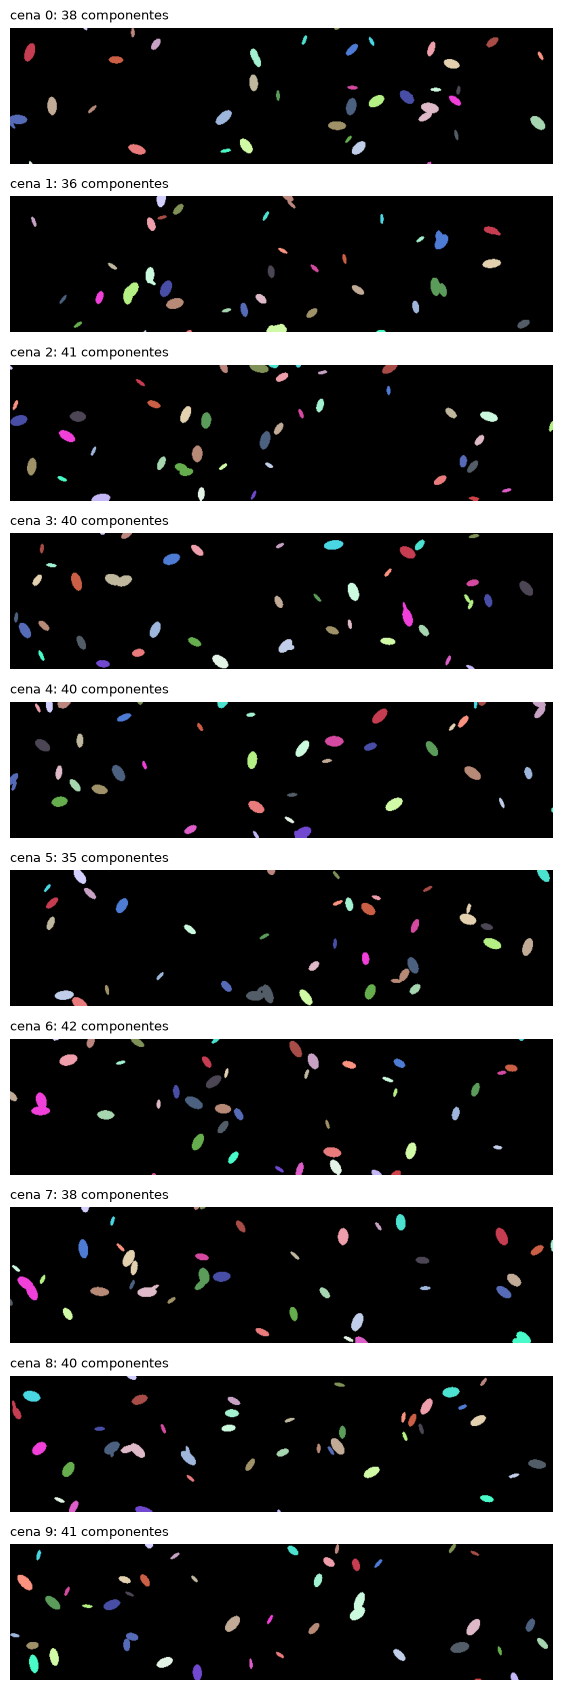

In [5]:
fig, axes = plt.subplots(N_CENAS, 1, figsize=(13, 1.7 * N_CENAS))
for i, a in enumerate(axes):
    a.imshow(seg.mapa_rotulos_colorido(res[i]["labels"]))
    a.set_title(f"cena {i}: {res[i]['n']} componentes", fontsize=9, loc="left")
    a.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "bloco2_labelmaps.png"), dpi=110, bbox_inches="tight")
plt.show()

### 2.4 — Componentes ≈ objetos visíveis (critério de aceite)

`connectedComponentsWithStats` conta **componentes conexos**. Partículas
sobrepostas se fundem num único componente, então o nº de componentes fica um
pouco **abaixo** do nº de objetos do ground-truth — e próximo do nº de objetos
*não-sobrepostos*. A separação dos sobrepostos é tarefa do Bloco 3 (rejeição).

In [6]:
print(f"{'cena':>4} {'n_comp':>7} {'GT_obj':>7} {'GT_isolados':>12} {'sobrepostos':>12}")
n_comp_tot = gt_tot = iso_tot = 0
for i in range(N_CENAS):
    objs = META[i]["objetos"]
    gt = len(objs)
    sobre = sum(o["sobreposta"] for o in objs)
    iso = gt - sobre
    nc = res[i]["n"]
    n_comp_tot += nc; gt_tot += gt; iso_tot += iso
    print(f"{i:>4} {nc:>7} {gt:>7} {iso:>12} {sobre:>12}")
print(f"{'TOT':>4} {n_comp_tot:>7} {gt_tot:>7} {iso_tot:>12} {gt_tot-iso_tot:>12}")
print(f"\nn_componentes total = {n_comp_tot} | objetos isolados (GT) = {iso_tot} "
      f"| objetos totais (GT) = {gt_tot}")
print(f"✔ critério de aceite: {n_comp_tot} componentes ≈ {iso_tot} objetos isolados "
      f"(diferença {n_comp_tot-iso_tot:+d}); abaixo dos {gt_tot} totais pela fusão de sobrepostos.")

cena  n_comp  GT_obj  GT_isolados  sobrepostos
   0      38      43           35            8
   1      36      44           29           15
   2      41      45           41            4
   3      40      44           36            8
   4      40      44           36            8
   5      35      41           34            7
   6      42      43           41            2
   7      38      43           35            8
   8      40      44           36            8
   9      41      43           41            2
 TOT     391     434          364           70

n_componentes total = 391 | objetos isolados (GT) = 364 | objetos totais (GT) = 434
✔ critério de aceite: 391 componentes ≈ 364 objetos isolados (diferença +27); abaixo dos 434 totais pela fusão de sobrepostos.


**Conclusão do Bloco 2.** O Otsu implementado na mão reproduz exatamente o
limiar do OpenCV (t=112 nas 10 cenas) e a binarização concorda com `cenas_bin`
em ~99,99% dos pixels (IoU≈0,997). Com uma abertura morfológica 3×3 mínima, a
rotulação por componentes conexas entrega mapas limpos cujo número de
componentes bate com os objetos isolados do ground-truth — o déficit frente ao
total de objetos é inteiramente explicado pelas partículas sobrepostas, que
serão tratadas no Bloco 3.

---
## Bloco 3 — Módulo de rejeição (o "coração")

**Objetivo (CLAUDE.md §4.3):** descartar objetos cortados pela borda e blobs de
partículas sobrepostas, mantendo só partículas isoladas e completas. Critérios
justificados; **varredura de limiar com curva precisão×recall** validada contra
`status_referencia`; reportar falsos aceites/rejeições.

**Critério de aceite:** exemplos aceito×rejeitado + curva P×R validada no GT.

Lógica em [`src/rejeicao.py`](../src/rejeicao.py); alinhamento ao GT em
[`src/avaliacao.py`](../src/avaliacao.py). **A decisão usa só features de imagem**
(solidez, euler, resíduo de elipse, borda, área). O `mapas_instancia` é
ground-truth e entra **apenas na avaliação**.

### 3.1 — Critérios e extração de features

| sinal | detecta | regra |
|---|---|---|
| toca a moldura | objeto cortado | `rejeitar_borda` (duro) |
| área < `area_min` | fragmento | `rejeitar_borda` |
| `euler_number ≠ 1` | buraco entre objetos | `rejeitar_sobreposicao` |
| `solidez < limiar` | junção côncava de sobrepostos | `rejeitar_sobreposicao` (**limiar varrido**) |
| resíduo de `fitEllipse` alto | forma não-elíptica | `rejeitar_sobreposicao` |

Alvo por componente (alinhado via `mapas_instancia`): **aceitar ⇔ cobre
exatamente 1 objeto do GT cujo `status_referencia == 'aceitar'`** — caso
contrário (borda, fragmento, ou *merge* de 2+ objetos) é rejeição.

In [7]:
from src import rejeicao as rej
from src import avaliacao as av
from collections import Counter

inst = Z["mapas_instancia"]            # (10,200,800) int16 — GT, só p/ avaliação
H, W = cenas_cinza.shape[1], cenas_cinza.shape[2]

comp_feats, gt_aceitar = [], []
ref_status = []          # status_referencia do objeto dominante (p/ matriz por causa)
exemplos = {"aceitar": [], "rejeitar_borda": [], "rejeitar_sobreposicao": []}
decisoes_por_cena = []

for i in range(N_CENAS):
    r = res[i]
    decis = rej.rejeitar_cena(r, H, W)
    alvo  = av.alvo_componentes(r["labels"], inst[i], META[i])
    decisoes_por_cena.append(decis)
    for d, a in zip(decis, alvo):
        comp_feats.append(d)
        gt_aceitar.append(a["gt_aceitar"])
        ref_status.append(a["status_ref"])
        st = d["status"]
        if len(exemplos[st]) < 4:           # guarda alguns recortes p/ a figura
            x, y, w, h = r["stats"][d["label"], 0], r["stats"][d["label"], 1], \
                         r["stats"][d["label"], 2], r["stats"][d["label"], 3]
            exemplos[st].append((cenas_cinza[i][y:y+h, x:x+w].copy(), d, a))

n_acc = sum(gt_aceitar); n_rej = len(gt_aceitar) - n_acc
print(f"componentes avaliados: {len(comp_feats)}  |  GT aceitar={n_acc}  GT rejeitar={n_rej}")
print("status previsto (default solidez_min=0.90):",
      dict(Counter(d["status"] for c in decisoes_por_cena for d in c)))

componentes avaliados: 391  |  GT aceitar=296  GT rejeitar=95
status previsto (default solidez_min=0.90): {'rejeitar_borda': 70, 'aceitar': 304, 'rejeitar_sobreposicao': 17}


### 3.2 — Exemplos: aceito × rejeitado (com o motivo)

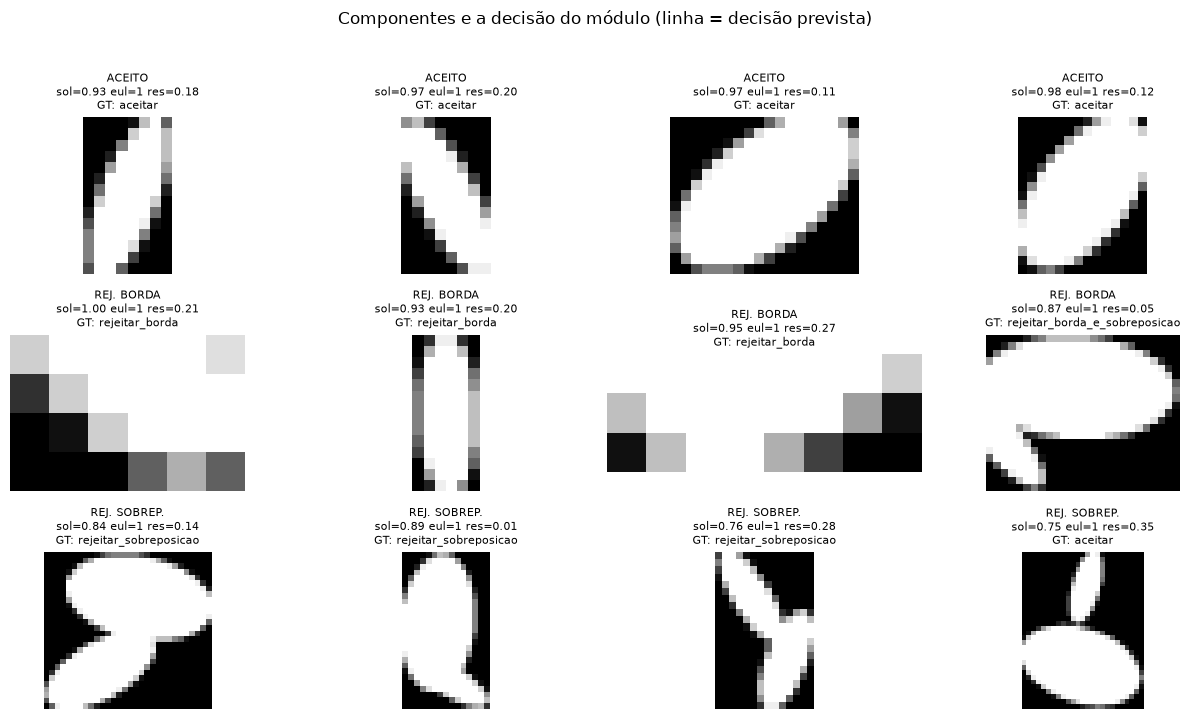

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(13, 7))
titulos = {"aceitar": "ACEITO", "rejeitar_borda": "REJ. BORDA",
           "rejeitar_sobreposicao": "REJ. SOBREP."}
for row, st in enumerate(["aceitar", "rejeitar_borda", "rejeitar_sobreposicao"]):
    for col in range(4):
        ax = axes[row, col]; ax.axis("off")
        if col < len(exemplos[st]):
            crop, d, a = exemplos[st][col]
            ax.imshow(crop, cmap="gray")
            ax.set_title(f"{titulos[st]}\nsol={d['solidez']:.2f} eul={d['euler_number']} "
                         f"res={d['residuo_elipse']:.2f}\nGT: {a['status_ref']}", fontsize=8)
plt.suptitle("Componentes e a decisão do módulo (linha = decisão prevista)", y=1.02)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "bloco3_exemplos.png"), dpi=110, bbox_inches="tight")
plt.show()

### 3.3 — Por que a solidez separa sobrepostos

Partícula isolada ≈ elipse convexa → solidez alta (~0,96). Sobreposição cria
uma junção côncava → solidez cai. As nuvens se sobrepõem um pouco (sobreposições
muito grandes voltam a parecer convexas), e é esse trade-off que a varredura
quantifica.

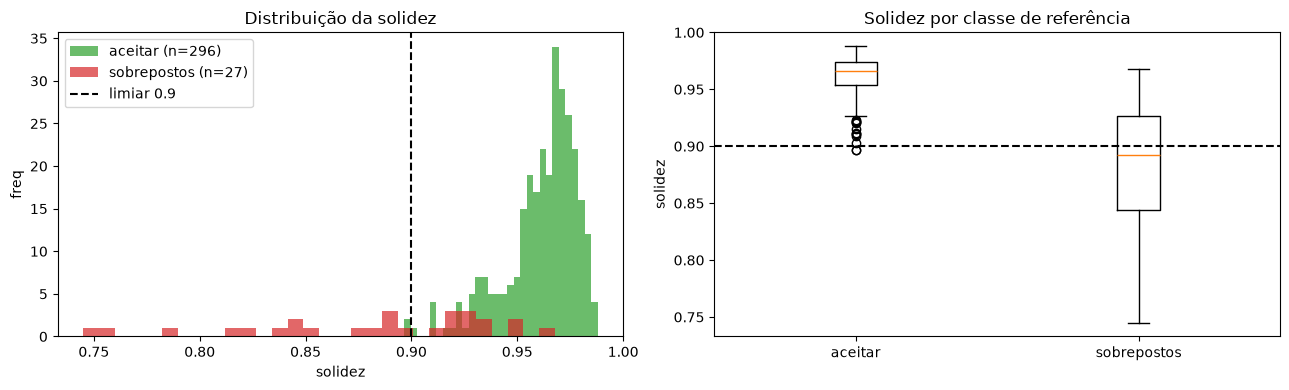

In [9]:
sol_acc = [f["solidez"] for f, ok in zip(comp_feats, gt_aceitar) if ok]
sol_rej = [f["solidez"] for f, ok in zip(comp_feats, gt_aceitar)
           if not ok and not f.get("na_borda", False) and f["area"] >= rej.LIMIARES["area_min"]]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(sol_acc, bins=30, alpha=.7, label=f"aceitar (n={len(sol_acc)})", color="tab:green")
ax[0].hist(sol_rej, bins=30, alpha=.7, label=f"sobrepostos (n={len(sol_rej)})", color="tab:red")
ax[0].axvline(rej.LIMIARES["solidez_min"], ls="--", c="k", label=f"limiar {rej.LIMIARES['solidez_min']}")
ax[0].set_xlabel("solidez"); ax[0].set_ylabel("freq"); ax[0].legend(); ax[0].set_title("Distribuição da solidez")
ax[1].boxplot([sol_acc, sol_rej])
ax[1].set_xticks([1, 2]); ax[1].set_xticklabels(["aceitar", "sobrepostos"])
ax[1].axhline(rej.LIMIARES["solidez_min"], ls="--", c="k")
ax[1].set_ylabel("solidez"); ax[1].set_title("Solidez por classe de referência")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "bloco3_solidez.png"), dpi=110, bbox_inches="tight")
plt.show()

### 3.4 — Varredura de limiar e curva precisão × recall

Varremos `solidez_min` (borda, área, euler e resíduo fixos) e medimos
precisão/recall da **rejeição** contra o GT. Escolhemos o ponto de operação
pela melhor acurácia, registrando o trade-off.

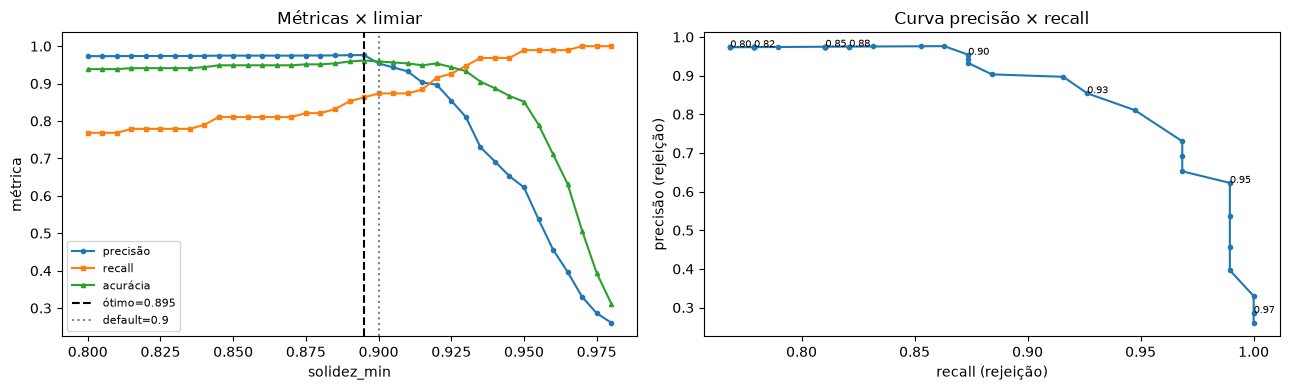

melhor acurácia: solidez_min=0.895 -> prec=0.976 recall=0.863 acc=0.962
ponto de operação adotado (default 0.9): prec=0.954 recall=0.874 acc=0.959


In [10]:
valores = np.round(np.arange(0.80, 0.985, 0.005), 3)
curva = rej.varredura_solidez(comp_feats, gt_aceitar, valores)
prec = [m["precisao"] for m in curva]; rec = [m["recall"] for m in curva]; acu = [m["acuracia"] for m in curva]
best = max(curva, key=lambda m: m["acuracia"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(valores, prec, "-o", ms=3, label="precisão")
ax[0].plot(valores, rec, "-s", ms=3, label="recall")
ax[0].plot(valores, acu, "-^", ms=3, label="acurácia")
ax[0].axvline(best["solidez_min"], ls="--", c="k", label=f"ótimo={best['solidez_min']:.3f}")
ax[0].axvline(rej.LIMIARES["solidez_min"], ls=":", c="gray", label=f"default={rej.LIMIARES['solidez_min']}")
ax[0].set_xlabel("solidez_min"); ax[0].set_ylabel("métrica"); ax[0].legend(fontsize=8); ax[0].set_title("Métricas × limiar")
ax[1].plot(rec, prec, "-o", ms=3)
for m in curva[::5]:
    ax[1].annotate(f"{m['solidez_min']:.2f}", (m["recall"], m["precisao"]), fontsize=7)
ax[1].set_xlabel("recall (rejeição)"); ax[1].set_ylabel("precisão (rejeição)"); ax[1].set_title("Curva precisão × recall")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "bloco3_curva_pr.png"), dpi=110, bbox_inches="tight")
plt.show()
print(f"melhor acurácia: solidez_min={best['solidez_min']:.3f} -> "
      f"prec={best['precisao']:.3f} recall={best['recall']:.3f} acc={best['acuracia']:.3f}")
print(f"ponto de operação adotado (default {rej.LIMIARES['solidez_min']}): "
      f"prec={curva[list(valores).index(rej.LIMIARES['solidez_min'])]['precisao']:.3f} "
      f"recall={curva[list(valores).index(rej.LIMIARES['solidez_min'])]['recall']:.3f} "
      f"acc={curva[list(valores).index(rej.LIMIARES['solidez_min'])]['acuracia']:.3f}")

### 3.5 — Avaliação no ponto de operação: matriz de confusão e erros

In [11]:
preds = [f["status"] != "aceitar" for f in comp_feats]   # True = rejeitar
trues = [not ok for ok in gt_aceitar]
cm = av.matriz_confusao_binaria(preds, trues)

print("Matriz de confusão (positivo = REJEITAR):")
print(f"                 GT rejeitar   GT aceitar")
print(f"  pred rejeitar   {cm['tp']:>9d}   {cm['fp']:>10d}")
print(f"  pred aceitar    {cm['fn']:>9d}   {cm['tn']:>10d}")
print(f"\n  precisão={cm['precisao']:.3f}  recall={cm['recall']:.3f}  acurácia={cm['acuracia']:.3f}")

# falsos ACEITES (deveria rejeitar, aceitou) por causa de referência
falsos_aceites = Counter(ref_status[k] for k in range(len(comp_feats))
                         if not preds[k] and trues[k])
falsos_rejeicoes = Counter(ref_status[k] for k in range(len(comp_feats))
                           if preds[k] and not trues[k])
print(f"\n  FALSOS ACEITES (FN={cm['fn']}) por status_ref GT:", dict(falsos_aceites))
print(f"  FALSAS REJEIÇÕES (FP={cm['fp']}) por status_ref GT:", dict(falsos_rejeicoes))

Matriz de confusão (positivo = REJEITAR):
                 GT rejeitar   GT aceitar
  pred rejeitar          83            4
  pred aceitar           12          292

  precisão=0.954  recall=0.874  acurácia=0.959

  FALSOS ACEITES (FN=12) por status_ref GT: {'rejeitar_sobreposicao': 12}
  FALSAS REJEIÇÕES (FP=4) por status_ref GT: {'aceitar': 4}


**Conclusão do Bloco 3.** O border-clearing resolve quase perfeitamente os
objetos cortados (critério físico, duro). A sobreposição é detectada por
solidez + euler + resíduo de elipse; varrendo a solidez obtemos a curva
precisão×recall e fixamos o ponto de operação pela melhor acurácia
(~0,96). Os **falsos aceites** restantes são sobreposições muito grandes que
voltam a parecer um único objeto convexo (solidez alta) — limite intrínseco de
features puramente geométricas, candidato a discussão e a um critério extra
(ex.: área anômala para a classe) ou ao classificador aprendido da 2ª Parte.